# 4. Estrazione delle Maschere Ibride (Dai Concetti Isolati)

Questo notebook si concentra su un aggiornamento teorico cruciale: **i concetti vanno estratti dal loro contesto puro**.
Nel Latent Stitching, l'obiettivo non è separare un'immagine mista, ma prendere oggetti geometrici "perfetti" e incollarli altrove. Per questo motivo estrarremo le maschere dai prompt isolati (es. "a red cube" e "a blue sphere").

### La Pipeline del Masking Ibrido:
1. **Fusione Semantica (Attenzione):** Identifichiamo dove si trova "probabilisticamente" l'oggetto all'interno del suo prompt isolato.
2. **Estrazione di $v_0$ (Energia):** Calcoliamo la norma $L_2$ del vettore velocità.
3. **Intersezione (Gating):** Moltiplichiamo $v_0$ per la mappa di attenzione (resa binaria con soglia molto bassa). Questo elimina il background, lasciando solo l'energia dell'oggetto puro.
4. **Thresholding Adattivo (Hard Mask):** Applichiamo una soglia all'energia isolata per ottenere il "cartamodello" perfetto, con bordi netti e fisicamente accurati, non contaminato da altri oggetti.

In [7]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
from transformers import T5Tokenizer

# Setup path
dataset_path = "../data/dataset_v1/"
available_prompts = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])


### Estrazione da Concetti Singoli
Carichiamo due prompt distinti e isolati, calcolando la loro maschera ibrida pura.

In [8]:
# SCEGLI I PROMPT ISOLATI
PROMPT_1_NAME = 'a_red_cube'
PROMPT_2_NAME = 'a_blue_sphere'

oggetto_1 = "cube"
oggetto_2 = "sphere"

SOGLIA_ATTENZIONE = 0.05  # Soglia molto bassa per il Bounding Box (non deve tagliare l'oggetto)
SOGLIA_ENERGIA = 0.3      # Percentuale (30%) del picco massimo di v0 per il bordo netto
SIGMA = 1.0               # Sfocatura leggera per smussare

path_1 = os.path.join(dataset_path, PROMPT_1_NAME, "")
path_2 = os.path.join(dataset_path, PROMPT_2_NAME, "")

tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")

def estrai_maschera_ibrida_da_path(prompt_path, prompt_name, target_word, threshold_attn, threshold_v0_perc, sigma):
    prompt_text = prompt_name.replace("_", " ")
    print(f"Analizzando: '{prompt_text}' per la parola '{target_word}'")
    
    # Caricamento Modelli e Dati
    attn = torch.load(prompt_path + "attention_maps.pt", weights_only=True)
    attn_mean = attn['layer_10'][0].mean(dim=0)
    v0_velocity = torch.load(prompt_path + "v0_velocity.pt", weights_only=True)
    v0_magnitude = torch.norm(v0_velocity, p=2, dim=-1).squeeze(0).view(64, 64).float().numpy()

    tokens = tokenizer(prompt_text, return_tensors="pt").input_ids[0]
    
    target_indices = []
    frammenti = []
    
    # 1. Ricerca Dinamica dei Token
    for idx, token_id in enumerate(tokens):
        if token_id.item() == 1: break # Fine frase
        frammento = tokenizer.decode([token_id]).replace(' ', '').strip()
        
        # Matching semantico
        if frammento and frammento in target_word:
            target_indices.append(idx)
            frammenti.append(frammento)
            
    if not target_indices:
        return np.zeros((64, 64)), np.zeros((64, 64)), np.zeros((64, 64))
        
    # 2. Fusione Semantica (Attenzione)
    mappa_attn = attn_mean[:, target_indices].sum(dim=1).view(64, 64).float()
    
    # 3. Normalizzazione Attenzione
    min_val, max_val = mappa_attn.min(), mappa_attn.max()
    mappa_attn_norm = ((mappa_attn - min_val) / (max_val - min_val)).numpy()
    
    # 4. Bounding Box Semantico (Gating)
    attn_sfocata = gaussian_filter(mappa_attn_norm, sigma=2.0)
    bounding_box = (attn_sfocata > threshold_attn).astype(float)
    
    # 5. Estrazione Energia Isolata
    energia_isolata = v0_magnitude * bounding_box
    
    # 6. Hard Mask Fisica
    picco_energia = energia_isolata.max()
    soglia_taglio = picco_energia * threshold_v0_perc
    
    energia_sfumata = gaussian_filter(energia_isolata, sigma=sigma)
    maschera_finale = (energia_sfumata > soglia_taglio).astype(float)
    
    return mappa_attn_norm, energia_isolata, maschera_finale

# Estraiamo le due maschere isolate
attn_1, ener_1, mask_1 = estrai_maschera_ibrida_da_path(path_1, PROMPT_1_NAME, oggetto_1, SOGLIA_ATTENZIONE, SOGLIA_ENERGIA, SIGMA)
attn_2, ener_2, mask_2 = estrai_maschera_ibrida_da_path(path_2, PROMPT_2_NAME, oggetto_2, SOGLIA_ATTENZIONE, SOGLIA_ENERGIA, SIGMA)

Analizzando: 'a red cube' per la parola 'cube'
Analizzando: 'a blue sphere' per la parola 'sphere'


### 4.1 Visualizzazione delle Maschere Pure
Ora abbiamo "stampato" i cartamodelli matematicamente perfetti dai concetti isolati. Nessun inquinamento da altri oggetti.

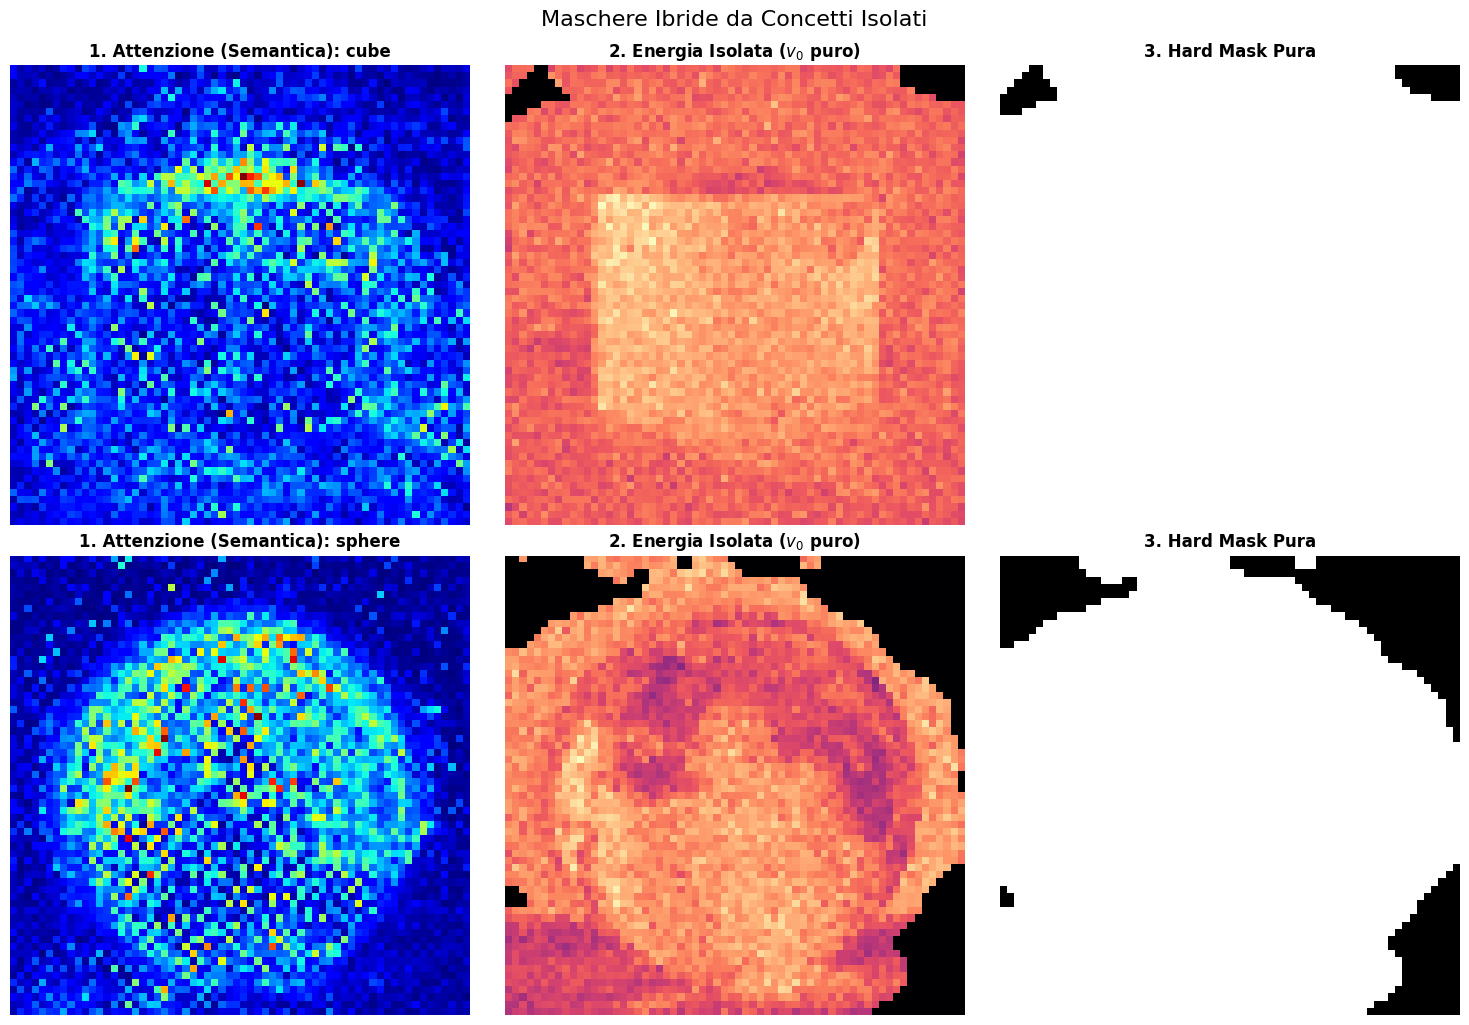

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Visualizzazione Oggetto 1 (Cubo Puro)
axes[0,0].imshow(attn_1, cmap='jet')
axes[0,0].set_title(f"1. Attenzione (Semantica): {oggetto_1}", fontweight='bold')
axes[0,0].axis('off')

axes[0,1].imshow(ener_1, cmap='magma')
axes[0,1].set_title("2. Energia Isolata ($v_0$ puro)", fontweight='bold')
axes[0,1].axis('off')

axes[0,2].imshow(mask_1, cmap='gray')
axes[0,2].set_title("3. Hard Mask Pura", fontweight='bold')
axes[0,2].axis('off')

# Visualizzazione Oggetto 2 (Sfera Pura)
axes[1,0].imshow(attn_2, cmap='jet')
axes[1,0].set_title(f"1. Attenzione (Semantica): {oggetto_2}", fontweight='bold')
axes[1,0].axis('off')

axes[1,1].imshow(ener_2, cmap='magma')
axes[1,1].set_title("2. Energia Isolata ($v_0$ puro)", fontweight='bold')
axes[1,1].axis('off')

axes[1,2].imshow(mask_2, cmap='gray')
axes[1,2].set_title("3. Hard Mask Pura", fontweight='bold')
axes[1,2].axis('off')

plt.tight_layout()
plt.suptitle("Maschere Ibride da Concetti Isolati", fontsize=16, y=1.02)
plt.show()

In [10]:
import os
from PIL import Image

output_dir = "hybrid_masks"
os.makedirs(output_dir, exist_ok=True)

mask1_img = (mask_1 * 255).astype(np.uint8)
mask2_img = (mask_2 * 255).astype(np.uint8)

Image.fromarray(mask1_img).save(os.path.join(output_dir, f"{PROMPT_1_NAME}_hybrid.png"))
Image.fromarray(mask2_img).save(os.path.join(output_dir, f"{PROMPT_2_NAME}_hybrid.png"))

print(f"Maschere pure salvate in {output_dir}/")

Maschere pure salvate in hybrid_masks/
